In [1]:
#Importar el modelo y describirlo superficilamente.

import torch
values = torch.load("Models/Model_Exec_710_Epoch_150_cpu_portable.pth", map_location="cpu", weights_only=False)
model = values["modelo"]
print(model)

CNN(
  (extraction): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (4): Conv2d(64, 64, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (12): Conv2d(64, 256, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): AvgPool2d(kernel_s

In [2]:
#Inspeccionar la arquitectura para entender exactamente que hace internamente

import inspect

print("Tipo de modelo:", type(model))
print(inspect.getsource(model.__class__.forward))

Tipo de modelo: <class 'DeepGA.Decoding.CNN'>
  def forward(self, x):
    '''Feature extraction'''
    prev = -1
    pos = 0
    outputs = {}
    features = self.features
    #print(x.shape)
    for i in range(len(features)):
      #print(f'Layer: {i}, Input shape: {x.shape}')
      if i == 0 or i == 1:
        #print("*features[i] =  ",*features[i])
        x = nn.Sequential(*features[i])(x)
        outputs[i] = x
        #print(f'Layer: {i}, Output shape: {x.shape}')

      else:
        connections = self.second_level[pos:pos+prev]
        #print(f'Layer: {i}, Connections: {connections}')
        for c in range(len(connections)):
          if connections[c] == 1:
            skip_size = self.sizes[c][0] #Size comming from previous layer
            req_size = x.shape[2] #Current feature map size
            #print(f'Layer: {i}, Skip connection from layer {c}, Skip size: {skip_size}, Required size: {req_size}')
            if skip_size > req_size:
              psize = skip_size - re

In [3]:
#Confirmamos el vector que entra al clasificador

model.eval()

def hook_fn(module, input, output):
    print("Entrada a classifier[0]:", input[0].shape)
    print("Salida de classifier[0]:", output.shape)

hook = model.classifier[0].register_forward_hook(hook_fn)

x = torch.randn(1, 1, 128, 128)  #El tamaño de la imagen para la red es de 128px además de estar en un solo canal

with torch.no_grad():
    y = model(x)
    print("Salida final del modelo:", y.shape)

hook.remove()

Entrada a classifier[0]: torch.Size([1, 1024])
Salida de classifier[0]: torch.Size([1, 64])
Salida final del modelo: torch.Size([1, 7])


Shape del embedding: torch.Size([1, 1024])
Primeros 20 valores:
tensor([0.3107, 0.0000, 0.2805, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.2596, 0.6023, 0.4935, 1.9492, 0.6750, 0.1624,
        0.7140, 0.6383])
Longitud: 1024
Mínimo: 0.0
Máximo: 2.290231
Media: 0.29149383
Std: 0.41671157

Primeros 50 valores:
[0.31070244 0.         0.28052658 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.25962812 0.60232973 0.49348012 1.9492115  0.67498493 0.16238005
 0.71399903 0.6382813  0.8822677  0.9076869  0.6052127  0.46162996
 0.33162475 1.1363708  0.42942196 1.5859267  0.40645504 0.
 0.44663537 0.         0.         0.06548684 0.         0.14839642
 0.47665322 0.733494   0.45893365 1.3493556  0.         0.
 0.         0.         0.         0.7546122  0.2916124  0.8983368
 0.04051972 0.07301828]


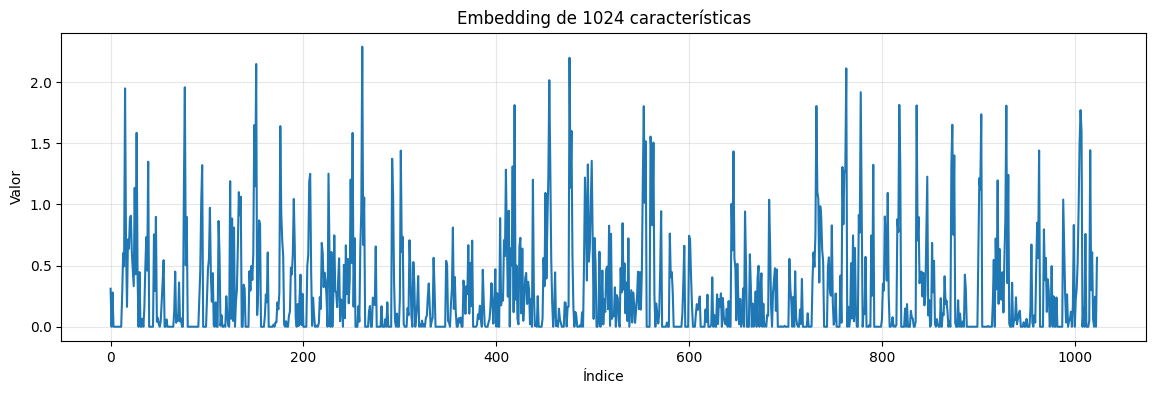

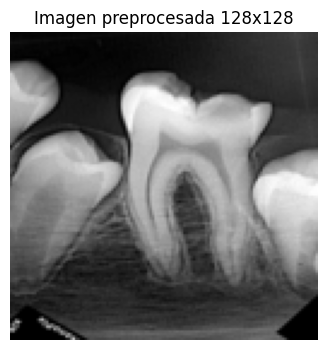

In [4]:
#Ver salidas reales del vecto antes de entrar a la clasificación.
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

model.eval()

# Ajusta esta ruta a una imagen real de tu dataset
img_path = "Tests/2. OD 36_aug1.jpg"

# Mismo preprocesamiento real del modelo
out_size = 128
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((out_size, out_size)),
    transforms.ToTensor(),
])

img_pil = Image.open(img_path)
x = transform(img_pil).unsqueeze(0)  # [1, 1, 128, 128]

captured = {}

def hook_fn(module, input, output):
    captured["embedding_1024"] = input[0].detach().cpu()

hook = model.classifier[0].register_forward_hook(hook_fn)

with torch.no_grad():
    y = model(x)

hook.remove()

embedding = captured["embedding_1024"]

print("Shape del embedding:", embedding.shape)
print("Primeros 20 valores:")
print(embedding[0, :20])

vec = embedding[0].numpy()

print("Longitud:", len(vec))
print("Mínimo:", vec.min())
print("Máximo:", vec.max())
print("Media:", vec.mean())
print("Std:", vec.std())

print("\nPrimeros 50 valores:")
print(vec[:50])

#Grafica
vec = embedding[0].numpy()

plt.figure(figsize=(14, 4))
plt.plot(vec)
plt.title("Embedding de 1024 características")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

#Imagen
plt.figure(figsize=(4,4))
plt.imshow(x[0, 0].cpu().numpy(), cmap="gray")
plt.title("Imagen preprocesada 128x128")
plt.axis("off")
plt.show()

Shape emb1: torch.Size([1, 1024])
Shape emb2: torch.Size([1, 1024])
Distancia L2: 7.96897029876709

--- Estadísticas emb1 ---
Min: 0.0
Max: 2.290231
Mean: 0.29149383
Std: 0.41671157

--- Estadísticas emb2 ---
Min: 0.0
Max: 2.012093
Mean: 0.19669275
Std: 0.29557213


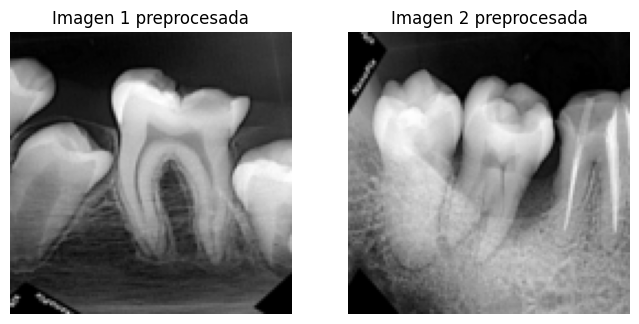

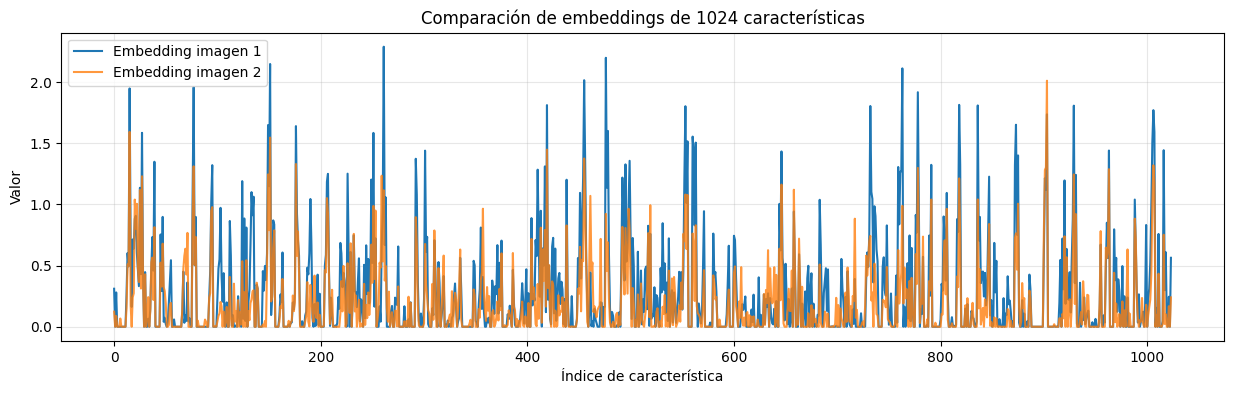

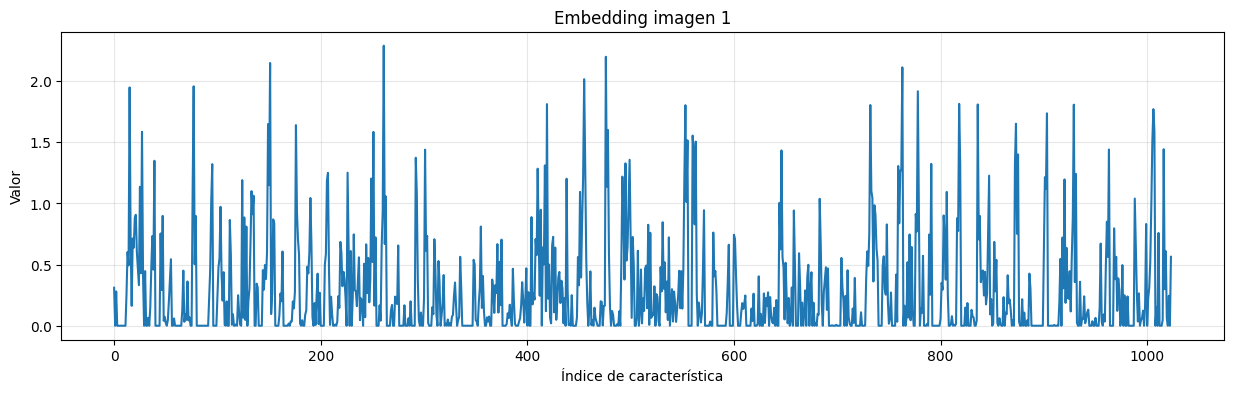

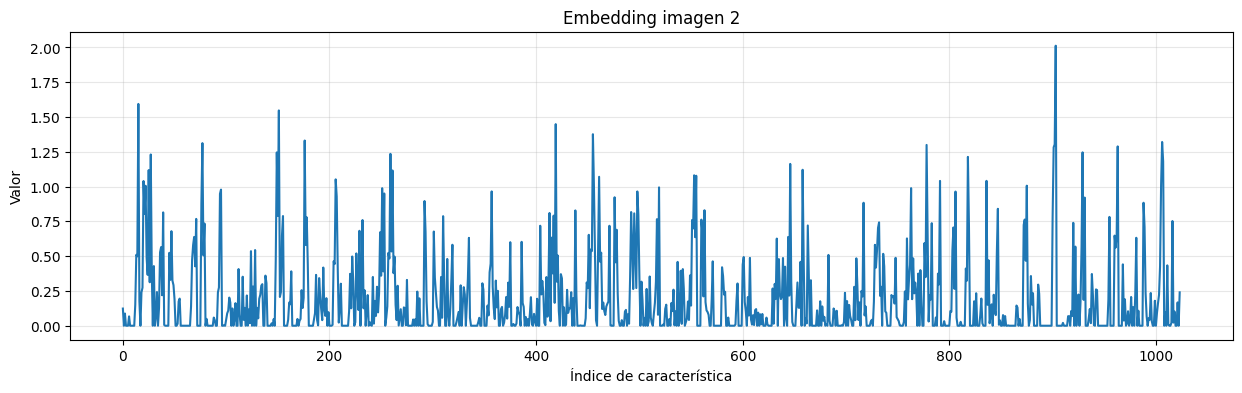

In [5]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Comparar vectores generados por dos imágenes
def get_embedding(model, img_path):
    model.eval()

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    img_pil = Image.open(img_path)
    x = transform(img_pil).unsqueeze(0)

    captured = {}

    def hook_fn(module, input, output):
        captured["embedding"] = input[0].detach().cpu()

    hook = model.classifier[0].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(x)

    hook.remove()
    return captured["embedding"], x, img_pil


emb1, x1, img1 = get_embedding(model, "Tests/2. OD 36_aug1.jpg")
emb2, x2, img2 = get_embedding(model, "Tests/2. OD 47_aug2.jpg")

print("Shape emb1:", emb1.shape)
print("Shape emb2:", emb2.shape)
print("Distancia L2:", torch.norm(emb1 - emb2).item())

vec1 = emb1[0].numpy()
vec2 = emb2[0].numpy()

print("\n--- Estadísticas emb1 ---")
print("Min:", vec1.min())
print("Max:", vec1.max())
print("Mean:", vec1.mean())
print("Std:", vec1.std())

print("\n--- Estadísticas emb2 ---")
print("Min:", vec2.min())
print("Max:", vec2.max())
print("Mean:", vec2.mean())
print("Std:", vec2.std())

# Mostrar imágenes preprocesadas
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(x1[0, 0].numpy(), cmap="gray")
plt.title("Imagen 1 preprocesada")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(x2[0, 0].numpy(), cmap="gray")
plt.title("Imagen 2 preprocesada")
plt.axis("off")

plt.show()

# Gráficas de los embeddings
plt.figure(figsize=(15, 4))
plt.plot(vec1, label="Embedding imagen 1")
plt.plot(vec2, label="Embedding imagen 2", alpha=0.8)
plt.title("Comparación de embeddings de 1024 características")
plt.xlabel("Índice de característica")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráficas separadas
plt.figure(figsize=(15, 4))
plt.plot(vec1)
plt.title("Embedding imagen 1")
plt.xlabel("Índice de característica")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(vec2)
plt.title("Embedding imagen 2")
plt.xlabel("Índice de característica")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

Concatenar Vectores

In [6]:
import torch
import torch.nn as nn

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.features
        self.second_level = base_model.second_level
        self.sizes = base_model.sizes

    def forward(self, image):
        x = image

        prev = -1
        pos = 0
        outputs = {}
        features = self.features

        for i in range(len(features)):
            if i == 0 or i == 1:
                x = nn.Sequential(*features[i])(x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]
                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = nn.Sequential(*features[i])(x)
                outputs[i] = x
                pos += prev

            prev += 1

        x = torch.flatten(x, 1)   # <- aquí sale el vector 1024
        return x

In [7]:
extractor = CNNEmbeddingExtractor(model)
extractor.eval()

image = torch.randn(1, 1, 128, 128)

with torch.no_grad():
    emb = extractor(image)

print(emb.shape)

torch.Size([1, 1024])


Vector clínico:
tensor([[0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.]])
Shape del vector clínico: torch.Size([1, 11])


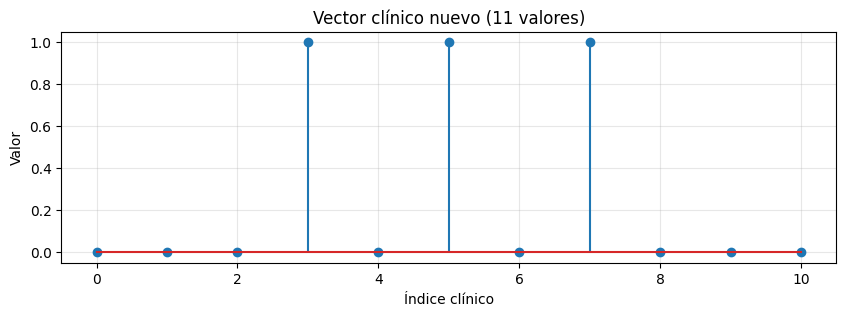

In [8]:
#Creamos el nuevo vector

import torch
import matplotlib.pyplot as plt

# Orden del vector clínico:
# [dx_paa, dx_aac, dx_pas, dx_tan, dx_aaa,
#  sensibilidad,
#  percusion,
#  movilidad_no_valorable, movilidad_1, movilidad_2,
#  palpacion]


#Solo es un ejemplo de como se verían los datos
clinical = torch.tensor([[0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0]], dtype=torch.float32) 

print("Vector clínico:")
print(clinical)
print("Shape del vector clínico:", clinical.shape)

clinical_vec = clinical[0].numpy()

plt.figure(figsize=(10, 3))
plt.stem(range(len(clinical_vec)), clinical_vec)
plt.title("Vector clínico nuevo (11 valores)")
plt.xlabel("Índice clínico")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
#Se unen los vectores

embedding = emb1   

fusion = torch.cat([embedding, clinical], dim=1) #Este es el vector ya fucionado correctamente

print("Shape embedding original:", embedding.shape)
print("Shape vector clínico:", clinical.shape)
print("Shape vector fusionado:", fusion.shape)

print("\nÚltimos 10 valores del embedding original:")
print(embedding[0, -10:])

print("\nVector clínico completo:")
print(clinical[0])

print("\nÚltimos 20 valores del vector fusionado:")
print(fusion[0, -20:])

Shape embedding original: torch.Size([1, 1024])
Shape vector clínico: torch.Size([1, 11])
Shape vector fusionado: torch.Size([1, 1035])

Últimos 10 valores del embedding original:
tensor([0.0000, 0.0459, 1.4438, 0.2988, 0.6094, 0.0610, 0.0000, 0.2452, 0.0000,
        0.5638])

Vector clínico completo:
tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])

Últimos 20 valores del vector fusionado:
tensor([0.0459, 1.4438, 0.2988, 0.6094, 0.0610, 0.0000, 0.2452, 0.0000, 0.5638,
        0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000,
        0.0000, 0.0000])


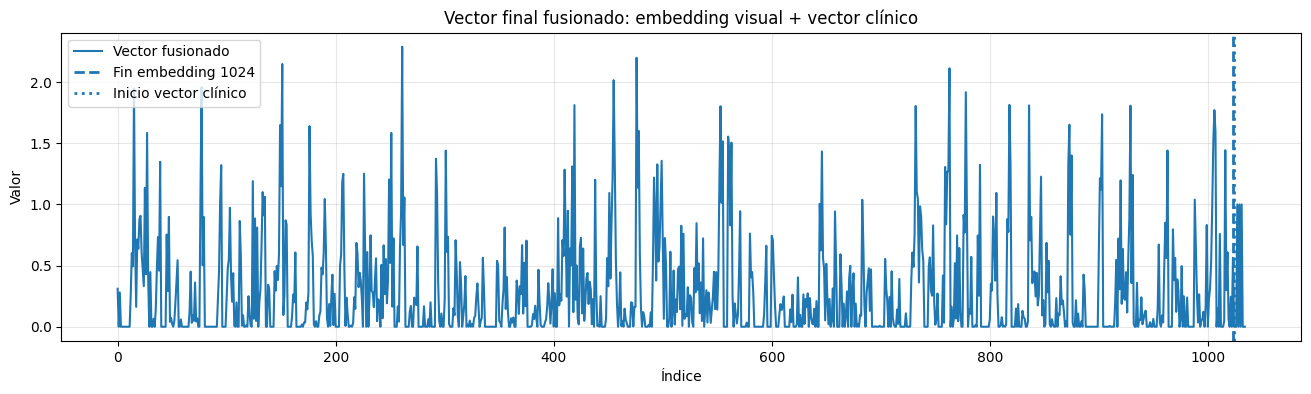

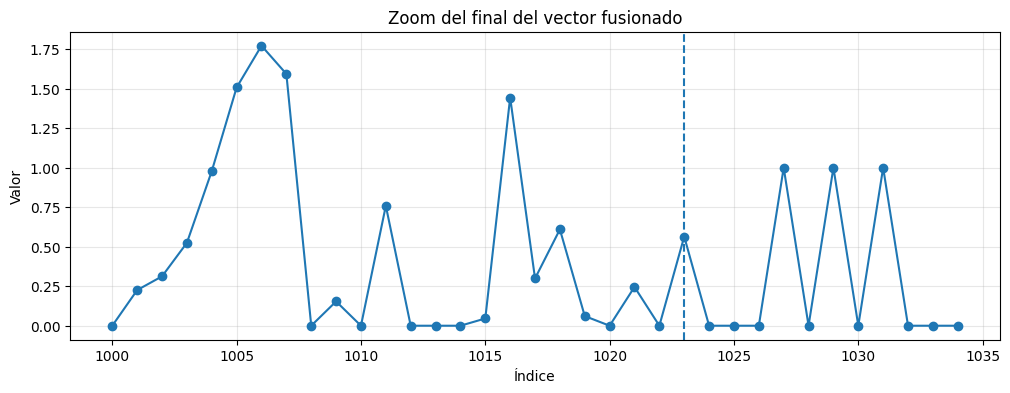

In [10]:
#Se puede ver la union

vec_emb = embedding[0].detach().cpu().numpy()
vec_clin = clinical[0].detach().cpu().numpy()
vec_fusion = fusion[0].detach().cpu().numpy()

plt.figure(figsize=(16, 4))
plt.plot(vec_fusion, label="Vector fusionado")
plt.axvline(x=1023, linestyle="--", linewidth=2, label="Fin embedding 1024")
plt.axvline(x=1024, linestyle=":", linewidth=2, label="Inicio vector clínico")
plt.title("Vector final fusionado: embedding visual + vector clínico")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(1000, 1035), vec_fusion[1000:1035], marker="o")
plt.axvline(x=1023, linestyle="--")
plt.title("Zoom del final del vector fusionado")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
#Probar que entre el vector nuevo y que salga la clasificación correcta.

new_classifier = nn.Sequential(
    nn.Linear(1035, 64),
    nn.ReLU(inplace=True),
    nn.Linear(64, 7)
)

new_classifier.eval()

with torch.no_grad():
    out = new_classifier(fusion)

print("Shape de entrada al nuevo clasificador:", fusion.shape)
print("Shape de salida:", out.shape)
print(out)

Shape de entrada al nuevo clasificador: torch.Size([1, 1035])
Shape de salida: torch.Size([1, 7])
tensor([[-0.2524, -0.1291, -0.1210, -0.0485, -0.0803,  0.0995, -0.0761]])


Prueba real del modelo fucionado sin entrenar

In [12]:
class_names = [
    "Necrosis pulpar",
    "Previamente iniciado",
    "Previamente tratado",
    "Pulpa normal",
    "Pulpitis irreversible asintomática",
    "Pulpitis irreversible sintomática",
    "Pulpitis reversible",
]

In [13]:
#Función para crear el tensor clínico a partir de los datos ingresados

def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    
    # Orden del vector clínico:
    # [dx_paa, dx_aac, dx_pas, dx_tan, dx_aaa,
    # sensibilidad,
    # percusion,
    # movilidad_no_valorable, movilidad_1, movilidad_2,
    # palpacion]


    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso Apical Crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso Apical Agudo":              [0, 0, 0, 0, 1],
    }

    bin_map = {
        "Positiva": 1.0,
        "Negativa": 0.0,
    }

    movilidad_map = {
        "No valorable": [1, 0, 0],
        "1":            [0, 1, 0],
        "2":            [0, 0, 1],
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    movilidad = str(movilidad)
    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor([vector], dtype=torch.float32)

In [14]:
#Función para extraer el vector original de 1024

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.features
        self.second_level = base_model.second_level
        self.sizes = base_model.sizes

    def forward(self, image):
        x = image

        prev = -1
        pos = 0
        outputs = {}
        features = self.features

        for i in range(len(features)):
            if i == 0 or i == 1:
                x = nn.Sequential(*features[i])(x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]
                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = nn.Sequential(*features[i])(x)
                outputs[i] = x
                pos += prev

            prev += 1

        x = torch.flatten(x, 1)
        return x

In [15]:
#Función para fusionar los vectores
import torch.nn as nn

class FusionClassifier(nn.Module):
    def __init__(self, input_dim=1035, num_classes=7):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )

    def forward(self, fused_vector):
        return self.classifier(fused_vector)

In [16]:
#Funcion para utilizar ambos modelos juntos

def predict_with_clinical_data(
    image_path,
    dx_periapical,
    sensibilidad,
    percusion,
    movilidad,
    palpacion,
    extractor,
    fusion_head,
    class_names
):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    # Cargar imagen
    img_pil = Image.open(image_path)
    x = transform(img_pil).unsqueeze(0)  # [1,1,128,128]

    # Crear vector clínico
    clinical = build_clinical_vector(
        dx_periapical=dx_periapical,
        sensibilidad=sensibilidad,
        percusion=percusion,
        movilidad=movilidad,
        palpacion=palpacion,
    )

    extractor.eval()
    fusion_head.eval()

    with torch.no_grad():
        embedding = extractor(x)                 # [1,1024]
        fused = torch.cat([embedding, clinical], dim=1)  # [1,1035]
        logits = fusion_head(fused)             # [1,7]
        probs = torch.softmax(logits, dim=1)    # probabilidades
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_class = class_names[pred_idx]

    # Mostrar imagen
    plt.figure(figsize=(4, 4))
    plt.imshow(x[0, 0].cpu().numpy(), cmap="gray")
    plt.title("Imagen preprocesada 128x128")
    plt.axis("off")
    plt.show()

    print("Vector clínico:")
    print(clinical)

    print("\nShape embedding:", embedding.shape)
    print("Shape fusionado:", fused.shape)
    print("Shape logits:", logits.shape)

    print("\nProbabilidades por clase:")
    for i, name in enumerate(class_names):
        print(f"{i}. {name}: {probs[0, i].item():.4f}")

    print(f"\nPredicción final: {pred_class} (índice {pred_idx})")

    return {
        "embedding": embedding,
        "clinical": clinical,
        "fused": fused,
        "logits": logits,
        "probs": probs,
        "pred_idx": pred_idx,
        "pred_class": pred_class,
    }

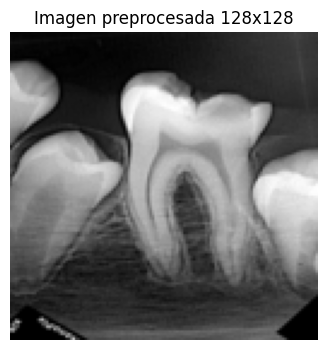

Vector clínico:
tensor([[0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.]])

Shape embedding: torch.Size([1, 1024])
Shape fusionado: torch.Size([1, 1035])
Shape logits: torch.Size([1, 7])

Probabilidades por clase:
0. Necrosis pulpar: 0.1222
1. Previamente iniciado: 0.1385
2. Previamente tratado: 0.1171
3. Pulpa normal: 0.1692
4. Pulpitis irreversible asintomática: 0.1588
5. Pulpitis irreversible sintomática: 0.1524
6. Pulpitis reversible: 0.1418

Predicción final: Pulpa normal (índice 3)


In [17]:
#Uso del nuevo modelo
cnn_extractor = CNNEmbeddingExtractor(model)
cnn_extractor.eval()
fusion_head = FusionClassifier(input_dim=1035, num_classes=7)
fusion_head.eval()

result = predict_with_clinical_data(
    image_path="Tests/2. OD 36_aug1.jpg",
    dx_periapical="Tejidos apicales normales",
    sensibilidad="Positiva",
    percusion="Negativa",
    movilidad="No valorable",
    palpacion="Negativa",
    extractor=cnn_extractor,
    fusion_head=fusion_head,
    class_names=class_names,
)

Crear el modelo nuevo como variable para usar

In [18]:
import copy
import torch
import torch.nn as nn

class StandaloneFusedDentalModel(nn.Module):
    def __init__(self, features, second_level, sizes, clinical_dim=11, num_classes=7):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in features
        ])

        self.second_level = copy.deepcopy(second_level)
        self.sizes = copy.deepcopy(sizes)

        self.clinical_dim = clinical_dim
        self.num_classes = num_classes

        self.classifier = nn.Sequential(
            nn.Linear(1024 + clinical_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )

    def extract_embedding(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]
                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])
                        elif skip_size == req_size:
                            x2 = outputs[c]
                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

    def forward(self, image, clinical_data):
        embedding = self.extract_embedding(image)
        fused = torch.cat([embedding, clinical_data.float()], dim=1)
        return self.classifier(fused)

In [19]:
standalone_fused_model = StandaloneFusedDentalModel(
    features=model.features,
    second_level=model.second_level,
    sizes=model.sizes,
    clinical_dim=11,
    num_classes=7
)

In [20]:
print(type(standalone_fused_model.features))

print(standalone_fused_model)

<class 'torch.nn.modules.container.ModuleList'>
StandaloneFusedDentalModel(
  (features): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): AvgPool2d(kernel_size=3, stride=2, padding=0)
    )
    (1): Sequential(
      (0): Conv2d(64, 64, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): AvgPool2d(kernel_size=3, stride=2, padding=0)
    )
    (3): Sequential(
      (0): Conv2d(64, 256, kerne

In [21]:
print(type(standalone_fused_model.features))
print(type(standalone_fused_model.second_level))
print(type(standalone_fused_model.sizes))

print("Número de bloques en features:", len(standalone_fused_model.features))
print("Longitud second_level:", len(standalone_fused_model.second_level))
print("Longitud sizes:", len(standalone_fused_model.sizes))

total_params = sum(p.numel() for p in standalone_fused_model.parameters())
trainable_params = sum(p.numel() for p in standalone_fused_model.parameters() if p.requires_grad)

print("Parámetros totales:", total_params)
print("Parámetros entrenables:", trainable_params)

for name, param in standalone_fused_model.named_parameters():
    print(name, param.shape)

<class 'torch.nn.modules.container.ModuleList'>
<class 'list'>
<class 'list'>
Número de bloques en features: 19
Longitud second_level: 153
Longitud sizes: 19
Parámetros totales: 3105023
Parámetros entrenables: 3105023
features.0.0.weight torch.Size([64, 1, 5, 5])
features.0.0.bias torch.Size([64])
features.0.1.weight torch.Size([64])
features.0.1.bias torch.Size([64])
features.1.0.weight torch.Size([64, 64, 9, 9])
features.1.0.bias torch.Size([64])
features.1.1.weight torch.Size([64])
features.1.1.bias torch.Size([64])
features.2.0.weight torch.Size([64, 64, 7, 7])
features.2.0.bias torch.Size([64])
features.2.1.weight torch.Size([64])
features.2.1.bias torch.Size([64])
features.3.0.weight torch.Size([256, 64, 9, 9])
features.3.0.bias torch.Size([256])
features.3.1.weight torch.Size([256])
features.3.1.bias torch.Size([256])
features.4.0.weight torch.Size([32, 320, 1, 1])
features.4.0.bias torch.Size([32])
features.4.1.weight torch.Size([32])
features.4.1.bias torch.Size([32])
features

In [22]:
#Función para usar el nuevo modelo
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

def predict_fused_model(
    model,
    image_path,
    dx_periapical,
    sensibilidad,
    percusion,
    movilidad,
    palpacion,
    class_names,
    show_image=True
):
    model.eval()

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    # Cargar imagen
    img_pil = Image.open(image_path)
    image_tensor = transform(img_pil).unsqueeze(0)  # [1,1,128,128]

    # Construir vector clínico
    clinical_tensor = build_clinical_vector(
        dx_periapical=dx_periapical,
        sensibilidad=sensibilidad,
        percusion=percusion,
        movilidad=movilidad,
        palpacion=palpacion,
    )

    # Predicción
    with torch.no_grad():
        logits = model(image_tensor, clinical_tensor)   # [1, 7]
        probs = torch.softmax(logits, dim=1)            # [1, 7]
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_class = class_names[pred_idx]

    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(image_tensor[0, 0].cpu().numpy(), cmap="gray")
        plt.title("Imagen preprocesada 128x128")
        plt.axis("off")
        plt.show()

    print("Vector clínico:")
    print(clinical_tensor)

    print("\nProbabilidades por clase:")
    for i, name in enumerate(class_names):
        print(f"{i}. {name}: {probs[0, i].item():.4f}")

    print(f"\nPredicción final: {pred_class} (índice {pred_idx})")

    return {
        "image_tensor": image_tensor,
        "clinical_tensor": clinical_tensor,
        "logits": logits,
        "probs": probs,
        "pred_idx": pred_idx,
        "pred_class": pred_class,
    }

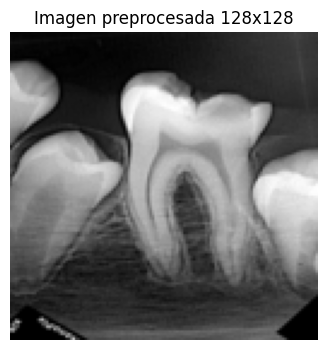

Vector clínico:
tensor([[0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.]])

Probabilidades por clase:
0. Necrosis pulpar: 0.1543
1. Previamente iniciado: 0.1444
2. Previamente tratado: 0.1381
3. Pulpa normal: 0.1300
4. Pulpitis irreversible asintomática: 0.1179
5. Pulpitis irreversible sintomática: 0.1505
6. Pulpitis reversible: 0.1649

Predicción final: Pulpitis reversible (índice 6)


In [23]:
result = predict_fused_model(
    model=standalone_fused_model,
    image_path="Tests/2. OD 36_aug1.jpg",
    dx_periapical="Tejidos apicales normales",
    sensibilidad="Positiva",
    percusion="Negativa",
    movilidad="No valorable",
    palpacion="Negativa",
    class_names=class_names,
    show_image=True
)